# Credit Card Users Churn Prediction

## Problem Statement

### Business Context

The Thera bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.


## Importing necessary libraries

In [80]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imbalanced-learn==0.10.1 xgboost==2.0.3 -q --user

In [81]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imblearn==0.12.0 xgboost==2.0.3 -q --user
# !pip install --upgrade -q threadpoolctl

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again*.

In [82]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import make_scorer, recall_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [84]:
#Load data to a variable
churn_data = pd.read_csv("/content/drive/MyDrive/Advanced_Machine_Learning/BankChurners.csv")

## Data Overview

- Observations
- Sanity checks

### Make a copy of the Churn **Dataset**

In [85]:
# Create a copy of the dataset
credit_card_data = churn_data.copy()

### Check the Shape of the Churn dataset

In [86]:
churn_data.shape

(10127, 21)

##### Observation:
* The dataset has 10127 rows and 21 columns

### Display the few rows of the credit_card_dataset

In [87]:
# Display the first 5 rows from the dataset
credit_card_data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000


In [88]:
# Display the last 5 rows of the data
credit_card_data.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.000,1851,2152.000,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,NaN,Divorced,$40K - $60K,Blue,25,4,2,3,4277.000,2186,2091.000,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.000,0,5409.000,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,NaN,$40K - $60K,Blue,36,4,3,3,5281.000,0,5281.000,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,6,2,4,10388.000,1961,8427.000,0.703,10294,61,0.649,0.189


### Check the datatypes of the credit_card_data columns

In [89]:
# Check the columns data type
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

##### Observation:
* There are 5 floats, 10 int64 and 6 object/string datatypes in the dataset.

### Missing Values check

In [90]:
# Checking or missiong values
credit_card_data.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,1519
Marital_Status,749
Income_Category,0
Card_Category,0
Months_on_book,0


#### Observation
* Only 2 columns have missing values i.e the education level and the marital status with a total of 1519 and 749 values missing respectively.

### Check for duplicate values in the credit_card_data

In [91]:
# checking for duplicate values
credit_card_data.duplicated().sum()

0

#### Observation:
* There are no duplicate values in the dataset

### View statistical summary of the credit_card_data

In [92]:
# views statistical summary of numerical columns
credit_card_data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000,10127.000
mean,739177606.334,46.326,2.346,35.928,3.813,2.341,2.455,8631.954,1162.814,7469.140,0.760,4404.086,64.859,0.712,0.275
std,36903783.450,8.017,1.299,7.986,1.554,1.011,1.106,9088.777,814.987,9090.685,0.219,3397.129,23.473,0.238,0.276
min,708082083.000,26.000,0.000,13.000,1.000,0.000,0.000,1438.300,0.000,3.000,0.000,510.000,10.000,0.000,0.000
25%,713036770.500,41.000,1.000,31.000,3.000,2.000,2.000,2555.000,359.000,1324.500,0.631,2155.500,45.000,0.582,0.023
50%,717926358.000,46.000,2.000,36.000,4.000,2.000,2.000,4549.000,1276.000,3474.000,0.736,3899.000,67.000,0.702,0.176
75%,773143533.000,52.000,3.000,40.000,5.000,3.000,3.000,11067.500,1784.000,9859.000,0.859,4741.000,81.000,0.818,0.503
max,828343083.000,73.000,5.000,56.000,6.000,6.000,6.000,34516.000,2517.000,34516.000,3.397,18484.000,139.000,3.714,0.999


#### Observation:
* The average customer age, Total relationship count, 12 Month inactive, Contact count within 12 months, Credit limit, Total Revolving balance, Avg Open to Buy, Total amount change between Q4 to Q1, Total transfer amount are 46.326 years, 3.813, 2.341, 2.455, 8631.954 dollars, 1162.814 dollars, 7469.140 dollars, 0.760 dollars, 4404.086 dollars respectively.

* The minimum customer age, Total relationship count, 12 Month inactive, Contact count within 12 months, Credit limit, Total Revolving balance, Avg Open to Buy, Total amount change between Q4 to Q1, Total transfer amount are 26 years, 1, 0, 0, 1438.3 dollars, 0 dollar, 3 dollars, 0 dollar, 510 dollars

In [93]:
# views statistical summary of string columns
credit_card_data.describe(include=["object"]).T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,8608,6,Graduate,3128
Marital_Status,9378,3,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


#### Observation:
* Existing Customers has the highest occurrence in the Attrition_Flag column with 8500 occurrence out of a total 10127 count.
* Account holder with the Graduate educational level does the highest transaction with a frequency of 3128 out of 8608.

* Customers/account holders with the "married" marital status does the highest transaction with a frequency of 4687 out of a total transaction of 9378 by customer with different marital status.

* The customers using the "Blue" credit card category executed the highest transaction with a transaction frequency of 9436 out of a total card_category action f 10127

#### Checking Unique Values in the Object Data type

In [94]:
# count the number of unique  values of items in the object columns
for col in credit_card_data.select_dtypes(include=['object']):
  print(f"Column {col}: {credit_card_data[col].nunique()} unique values")

Column Attrition_Flag: 2 unique values
Column Gender: 2 unique values
Column Education_Level: 6 unique values
Column Marital_Status: 3 unique values
Column Income_Category: 6 unique values
Column Card_Category: 4 unique values


##### Observation
The folliwing are the unuque value counts
* Column Attrition_Flag: 2 unique values
* Column Gender: 2 unique values
* Column Education_Level: 6 unique values
* Column Marital_Status: 3 unique values
* Column Income_Category: 6 unique values
* Column Card_Category: 4 unique values

In [95]:
for i in credit_card_data.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(credit_card_data[i].value_counts())
    print("*" * 50)

Unique values in Attrition_Flag are :
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
F    5358
M    4769
Name: count, dtype: int64
**************************************************
Unique values in Education_Level are :
Education_Level
Graduate         3128
High School      2013
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
**************************************************
Unique values in Marital_Status are :
Marital_Status
Married     4687
Single      3943
Divorced     748
Name: count, dtype: int64
**************************************************
Unique values in Income_Category are :
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
abc               1112
$120K +            727
Name: count, dtype: int64
********************

### Dropping the CLIENTNUM Column

In [96]:
# Drop the CLIENTNUM column as it will not be useful in the analysis
credit_card_data.drop(["CLIENTNUM"], axis=1, inplace=True)

### Encoding the Attrition_Flag column

In [97]:
## Encoding Attrited and Existing customer to 1 and 0 respectively, for analysis
credit_card_data['Attrition_Flag'] = credit_card_data['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. How is the total transaction amount distributed?
2. What is the distribution of the level of education of customers?
3. What is the distribution of the level of income of customers?
4. How does the change in transaction amount between Q4 and Q1 (`total_ct_change_Q4_Q1`) vary by the customer's account status (`Attrition_Flag`)?
5. How does the number of months a customer was inactive in the last 12 months (`Months_Inactive_12_mon`) vary by the customer's account status (`Attrition_Flag`)?
6. What are the attributes that have a strong correlation with each other?



#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [98]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [99]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = int(p.get_height()) #p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [100]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [101]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Answers to EDA Questions

#### Answer 1
* Total transaction distribution amount

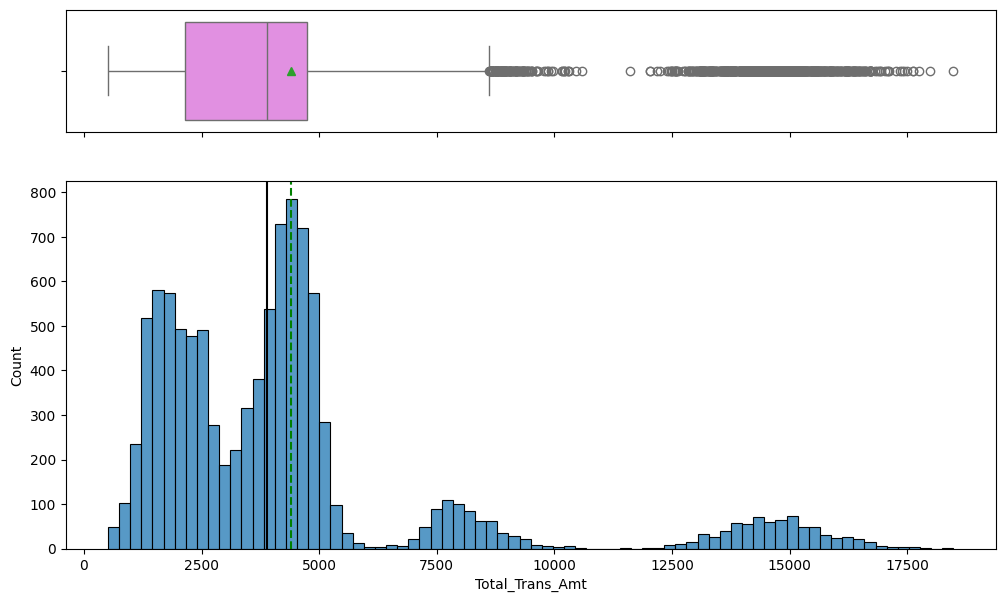

In [102]:
histogram_boxplot(credit_card_data, "Total_Trans_Amt")

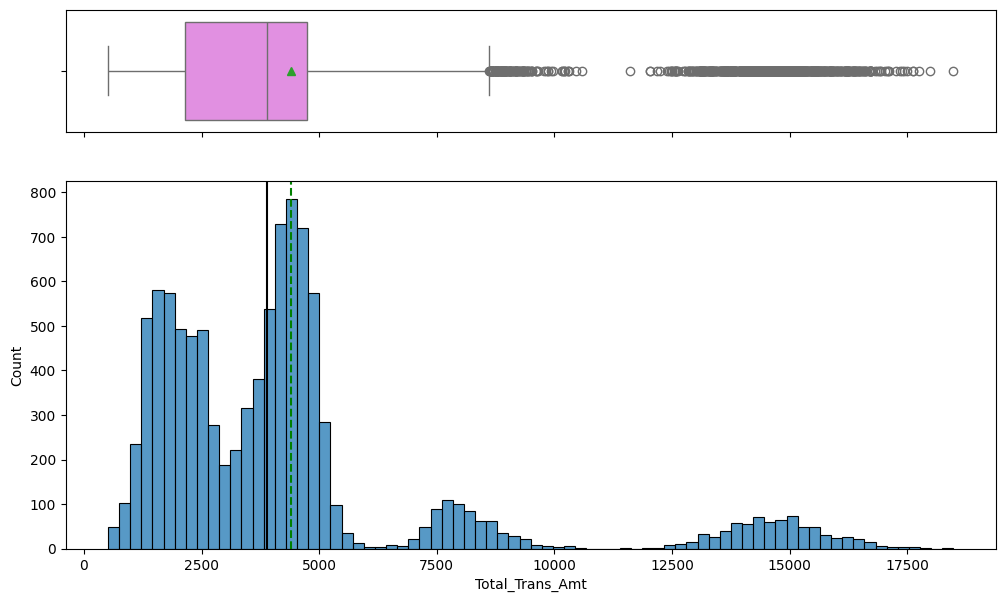

In [103]:
# prompt: How is the total transaction amount distributed? include explanation

histogram_boxplot(credit_card_data, "Total_Trans_Amt")


##### Observation:
* The total transaction amount is positively skewed
* Most of the total transaction amount falls between 0 to 5000 dollars.


#### Answer 2
* Distribution of the level of education of customers?

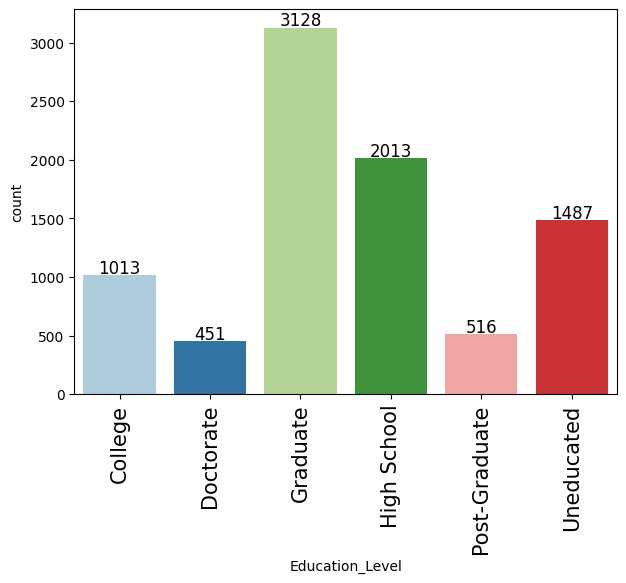

In [104]:
# Checking the distribution of customers basedon educational level
labeled_barplot(credit_card_data, "Education_Level")

##### Observations
* Based on the graph it is seen that most of the account holders/customers are Graduate customers, accounting to 3128 customers of the total customers.
* The least number of customers based on education level are customers with doctorate education level
* The high school customers consistute the second to the highest number of customers totalling 2013 customer of the bank.

In [105]:
# Check the count of various educations levels
credit_card_data['Education_Level'].value_counts()

,count
Education_Level,
Graduate,3128
High School,2013
Uneducated,1487
College,1013
Post-Graduate,516
Doctorate,451


In [106]:
credit_card_data['Education_Level'].value_counts().sum()

8608

#### Answer 3
* The distribution of the level of income of customers

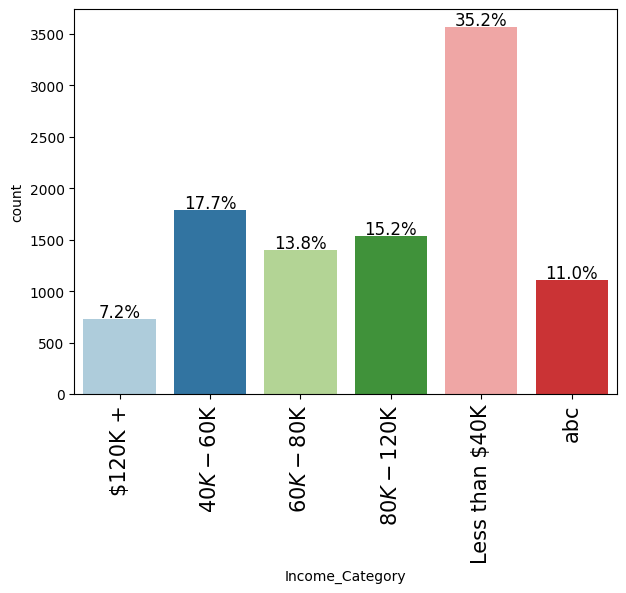

In [107]:
# Label plot for the distribution of customers income level
labeled_barplot(credit_card_data, "Income_Category", perc=True)

##### Observations:
* 35.2% of the customers have their income less than 40K USD.
* Customers with income less than 40K USD constitute the highest number of customers in the bank
* Customers with income of 120K + USD constitute 7.2% and the least number of customers in the bank

* Customers with unknown income category consistutes 11% of the total customers in the bank.


#### Answer 4
* How the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer's account status (Attrition_Flag)

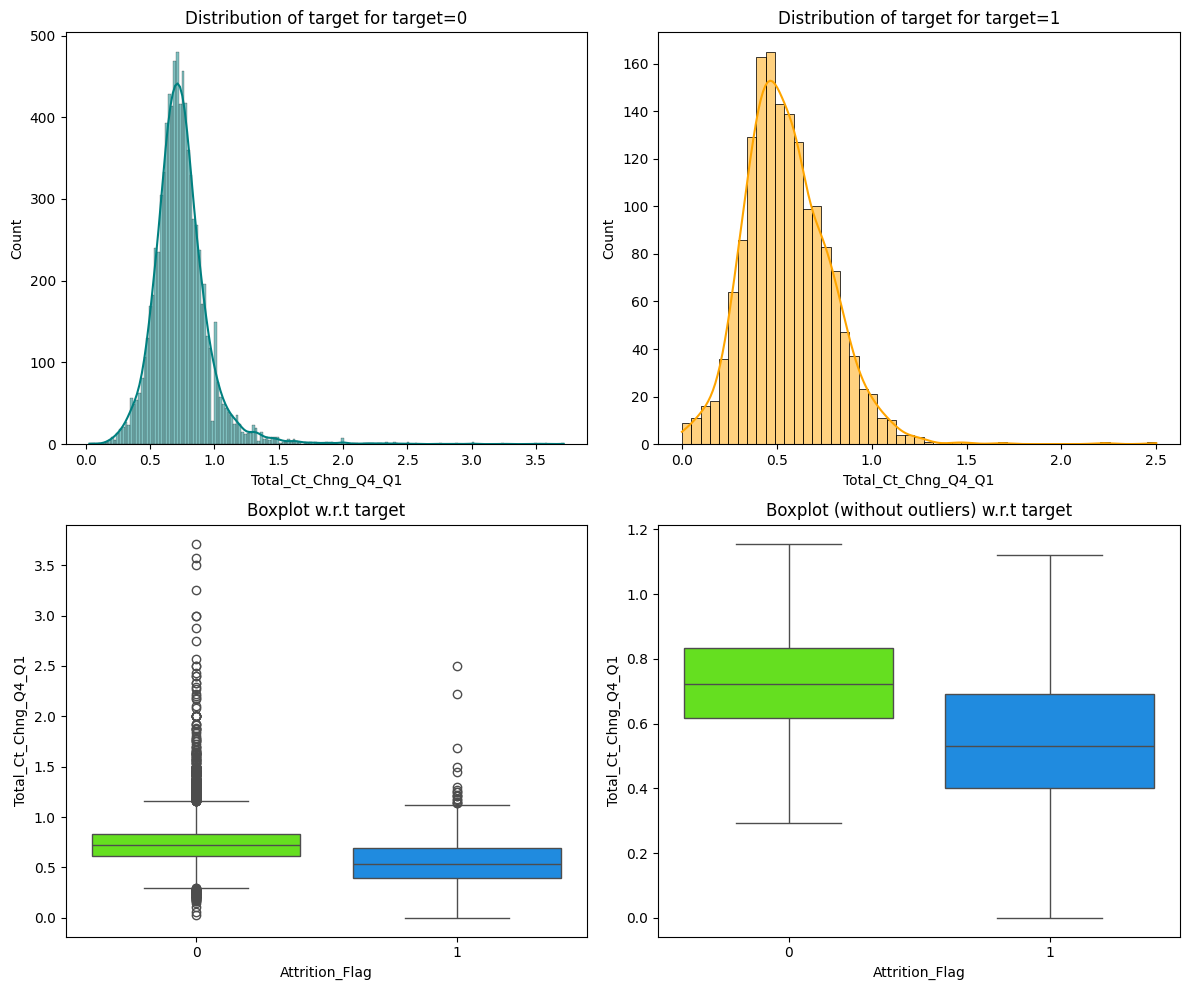

In [108]:
# total_ct_change_Q4_Q1 variance by Attrition Flag
distribution_plot_wrt_target(
    credit_card_data, "Total_Ct_Chng_Q4_Q1", "Attrition_Flag"
)

In [109]:
#show unique values of the content of attrition flag
credit_card_data['Attrition_Flag'].unique()

array([0, 1])

##### Observations:
**Note :** Attrited customer = 1 and Existing customer = 0

* The distribution of Total_Ct_Chng_Q4_Q1 for both Existing and Attrited customers are positively skewed.
* 75% of the Total_Ct_Chng_Q4_Q1 for existing customer is above 0.8 while it is lower for the Attrited customer at less than 0.7.
* Attrited customers have the highest Total_Ct_Chng_Q4_Q1
* Existing customers have the least Total_Ct_Chng_Q4_Q1
* There are outliers present in the data for both the categories.


#### Answer 5
* How the number of months a customer was inactive in the last 12 months (Months_Inactive_12_mon) vary by the customer's account status (Attrition_Flag)?

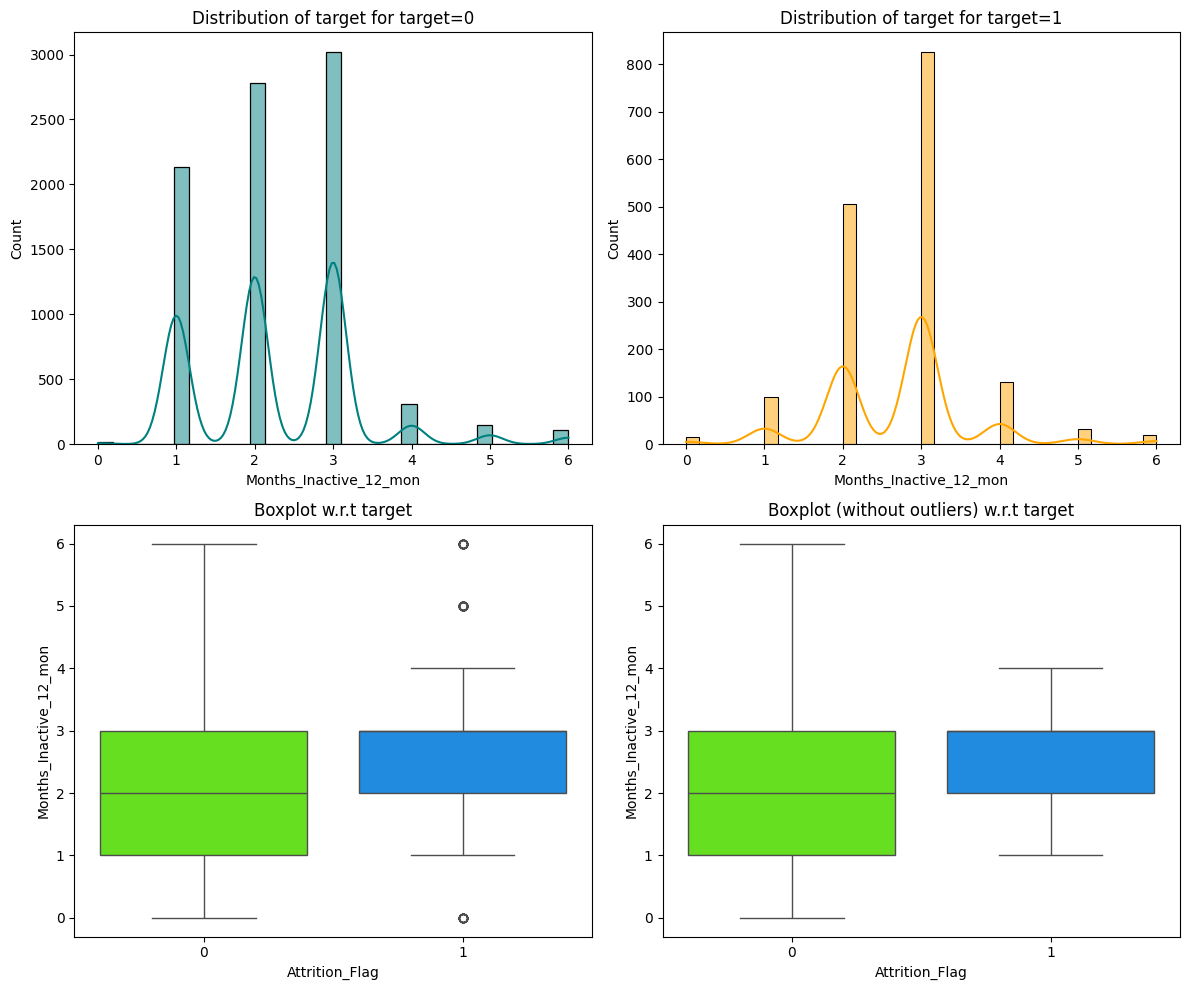

In [110]:
# Number of months customers were inactive in the last 12 months
distribution_plot_wrt_target(credit_card_data, "Months_Inactive_12_mon", "Attrition_Flag")

##### Observation
**Note :** Attrited customer = 1 and Existing customer = 0
* The existing customer distribution is positively skewed
* 75% of the customer for both categories were inactive for atleast 3 months.
* 25% of the Attrited customers were inactive for atleast 2 months.
* Most of the customers were inactive for atleast 3 months
* Existing customers had the highest number of customers that were inactive.


#### Answer 6
* The attributes that have a strong correlation with each other?

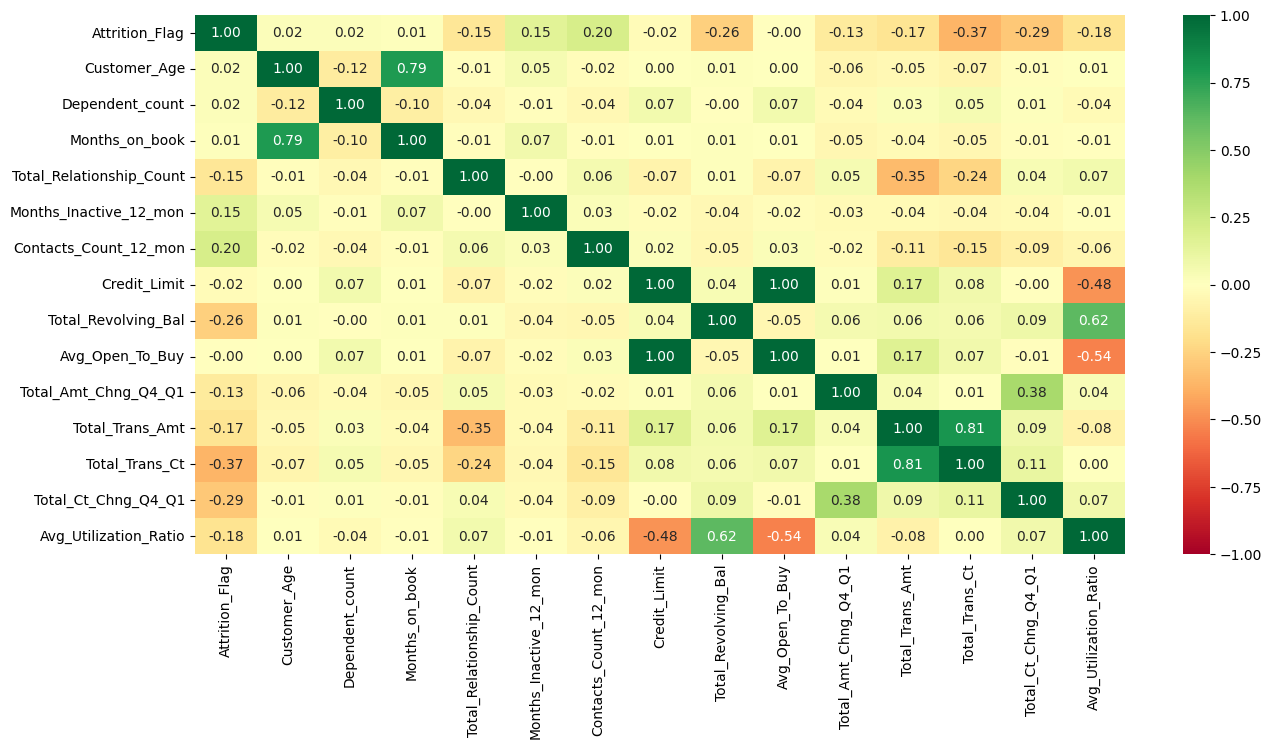

In [111]:
# Checking the correlation of variables
credit_card_data_numeric = credit_card_data.select_dtypes(include=['number']) #Selecting only numerical values

plt.figure(figsize=(15, 7)) # Sets the size of the graph
sns.heatmap(
    credit_card_data_numeric.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="RdYlGn"
)
plt.show() # Displays the heatmap

##### Observations:
* Customer_Age and Months_on_Book has a strong positive correlation of 0.79. Older customers tend to have been longer with the bank.
* The Ave_Open_To_Buy and Credit_limit have a very strong correlation (1) indicating that as the credit limit increases, the average open to buy also increases.
* Credit_limit and Avg_Utilization_Ratio have negative correlation. That indicates that higher  credit limits are associated with lower utilization.
* Total_Trans_Amt and Total_Trans_Ct have a strong positive correlation (0.81), indicating that customers with higher transaction amounts have a higher count of transactions. This reflect consistent spending behaviour amoong active customers.
* Ave_Open_To_Buy and Avg_Utilization_Ratio have the weakest negative correlation.
* Total_Amt_Chng_Q4_Q1 and Total_Ct_Chng_Q4_Q1 have a moderate positive correlation (0.38). This implies that changes in transaction amounts are correlated with changes in transaction counts.
* Total_Revolving_Bal and Avg_Utilization_Ratio have a strong positive correlation (0.62).


## Data Pre-processing

### Detecting Outliers

In [112]:
Q1 = credit_card_data_numeric.quantile(0.25)  # To find the 25th percentile
Q3 = credit_card_data_numeric.quantile(0.75)  # To find the 75th percentile

IQR = Q3 - Q1  # Inter Quantile Range (75th perentile - 25th percentile)

# Finding lower and upper bounds for all values. All values outside these bounds are outliers
lower = (Q1 - 1.5 * IQR)
upper = (Q3 + 1.5 * IQR)

In [113]:
# checking the % outliers
((credit_card_data.select_dtypes(include=["float64", "int64"]) < lower) | (credit_card_data.select_dtypes(include=["float64", "int64"]) > upper)).sum() / len(credit_card_data) * 100

,0
Attrition_Flag,16.066
Customer_Age,0.020
Dependent_count,0.000
Months_on_book,3.812
Total_Relationship_Count,0.000
Months_Inactive_12_mon,3.268
Contacts_Count_12_mon,6.211
Credit_Limit,9.717
Total_Revolving_Bal,0.000
Avg_Open_To_Buy,9.509


#### Observation:
* Attrition_Flag has the highest outliers (16.066)
* Credit_Limit has the second highest outliers (9.717)

### Train-Test Split

In [114]:
# Make a copy of the dataframe
credit_card_data_copy = credit_card_data.copy()

In [115]:
#List unique values in income category
credit_card_data_copy['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'abc'], dtype=object)

In [116]:
credit_card_data_copy.isna().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,1519
Marital_Status,749
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


##### Observation:
* There are two columns (Education_Level and Marital_Status) with missing values.
* The Education_Level	has 1519 missing values and Marital_Status has 749 missing values


In [117]:
# Replace the anomalous values in Income_Category with NaN
credit_card_data_copy['Income_Category'] = credit_card_data_copy['Income_Category'].replace('abc', np.nan)

In [118]:
X = credit_card_data_copy.drop(columns=['Attrition_Flag'])
Y = credit_card_data_copy['Attrition_Flag']

In [119]:
# Splitting data into train, validation and test set:

# first we split data into 2 parts, train and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=Y
)

# then we split temporary into test and validation set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(7088, 19) (1519, 19) (1520, 19)


#### Observations:
* There are 7088 rows and 19 columns in the X_train (training) dataset.
* There are 1519 rows and 19 columns in the X_val (validation) dataset
* There are 1520 rows and 19 columns in the X_test (test) dataset.

## Missing value imputation




In [120]:
# Define the categorical columns
categorical_cols = ['Education_Level', 'Marital_Status', 'Income_Category']

# Using Simple Imputer to treat missing values, using 'most_frequent' strategy
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit and transform the training data
X_train[categorical_cols] = imputer_cat.fit_transform(X_train[categorical_cols])

# Fit and transform the validation data
X_val[categorical_cols] = imputer_cat.fit_transform(X_val[categorical_cols])

# Fit and transform the test data
X_test[categorical_cols] = imputer_cat.fit_transform(X_test[categorical_cols])

In [121]:
#Check missing values in X_train
missing_values_train = X_train.isnull().sum()
print("Missing Values in X_train")
print(missing_values_train)

#Check missing values in X_val
missing_values_val = X_val.isnull().sum()
print("Missing Values in X_val")
print(missing_values_val)

#Check missing values in X_test
missing_values_test = X_val.isnull().sum()
print("Missing Values in X_test")
print(missing_values_test)

Missing Values in X_train
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
Missing Values in X_val
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_R

#### Observations:
* There are no more missing values.

### Encoding the categorical variables

In [122]:
# Encoding the categorical variables
X_train = pd.get_dummies(X_train, drop_first=True) # Encode the train data
X_val = pd.get_dummies(X_val, drop_first=True) # Encode the validation data
X_test = pd.get_dummies(X_test, drop_first=True) # Encode the test data

# Print the shape of the X_train, X_val and the X_test
print(X_train.shape, X_val.shape, X_test.shape)


(7088, 29) (1519, 29) (1520, 29)


#### Observation:
* The number of columns have changed from 19 columns to 29 columns after encoding the data.
* The X_train (training) dataset has  7088 rows and 29 columns.
* The X_val (validation) dataset has 1519 rows and 29 columns.
* There are 1520 rows and 29 columns in the X_test (test) dataset.

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [123]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

In [124]:
# defining a function to create the confusion matrix using sklearn
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building with original data

### Initial model building with original data

In [125]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
#models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9850746268656716
Random forest: 1.0
Gradient Boosting: 0.8902546093064091
Decision Tree: 1.0
AdaBoost: 0.8410886742756805

Validation Performance:

Bagging: 0.8442622950819673
Random forest: 0.7704918032786885
Gradient Boosting: 0.8483606557377049
Decision Tree: 0.8073770491803278
AdaBoost: 0.8565573770491803


##### Observation:
* The AdaBoost has the best validation performance with a recall score of (85.66% approximately)
* The Gradient Boosting has the second best validation performance with a recall score of (84.84% approximately)
* Random forest has the least performance with a recall score of 77.05% approximately.
* The Random forest and Decision Tree has the highest performance on the training data with a recall of 100%

### Model Building with Oversampled data


In [126]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [127]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
#models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.998150949739452
Random forest: 1.0
Gradient Boosting: 0.979660447133972
Decision Tree: 1.0
AdaBoost: 0.9695747184400739

Validation Performance:

Bagging: 0.860655737704918
Random forest: 0.860655737704918
Gradient Boosting: 0.930327868852459
Decision Tree: 0.8483606557377049
AdaBoost: 0.889344262295082


##### Observation:
* The Gradient Boosting has the best validation data performance with a recall score of 93.03% after over sampling.
* The AdaBoost has the second best validation data performance with a recall score of 88.93% after over sampling.
* Decision Tree has the least validation data performance with a recall score of 84.84% approximately after over sampling.
* The Random forest and Decision Tree has the highest performance on the training data with a recall of 100% after over sampling.

### Model Building with Undersampled data

In [128]:
# Using Random undersampler to under sample the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [129]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
#models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n") # print the string in a new line
for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores = recall_score(y_train_under, model.predict(X_train_under))
    print("{}: {}".format(name, scores)) #  print the name of the model and their recall scores

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9885864793678666
Random forest: 1.0
Gradient Boosting: 0.9754170324846356
Decision Tree: 1.0
AdaBoost: 0.9446883230904302

Validation Performance:

Bagging: 0.930327868852459
Random forest: 0.9344262295081968
Gradient Boosting: 0.9590163934426229
Decision Tree: 0.9057377049180327
AdaBoost: 0.9467213114754098


##### Observation:
* The Gradient Boosting has the best validation data performance with a recall score of 95.90% after under sampling.
* The AdaBoost has the second best validation data performance with a recall score of 94.67% after under sampling.
* Decision Tree has the least validation data performance with a recall score of 90.57% after under sampling.
* The Random forest and Decision Tree has the highest performance on the training data with a recall of 100% after under sampling.

### HyperparameterTuning

#### Sample Parameter Grids

**Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase


- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost (optional):

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```

#### Tuning Gradient Boosting with undersampled data

In [130]:
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.05, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.7963250637607233:


In [131]:
# Creating new pipeline with best parameters
tuned_gbunder = GradientBoostingClassifier(init=DecisionTreeClassifier(random_state=1),learning_rate=0.05,max_features=0.7,n_estimators=100,subsample=0.7,random_state=1)

# Fit the model on training data
tuned_gbunder.fit(X_train_under, y_train_under)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_gbunder, X_train_under, y_train_under))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_gbunder, X_val, y_val))


Train Performance:
   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.895   0.906      0.617 0.734


##### Observation:
* The Gradient Boosting with undersampled data has a recall score of 90.6% performance on the validation data after hyperparameter tuning.

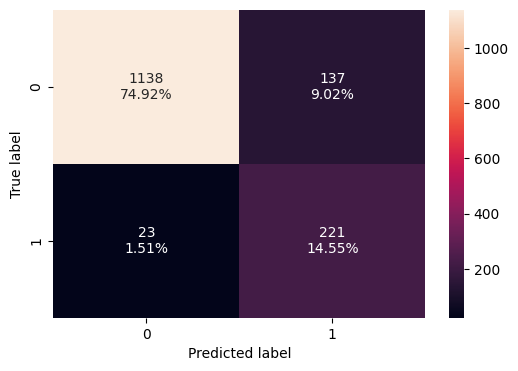

In [132]:
#Create the confusion matrix
confusion_matrix_sklearn(tuned_gbunder, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 74.92%.
* The model has a moderate True Positive (TP) rate predicted at 14.55%.
* The model shows a high overall accuracy of 89.47%, indicating that it performs well on the given dataset. * The high recall of 90.6% approximately indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 10.53% of the instances wrongly

#### Tuning Adaboosting with undersampled data

In [133]:
# Check Adaboosting model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8577904011129146:


In [134]:
# Creating new pipeline with best parameters
tuned_adbunder = AdaBoostClassifier(n_estimators=100,learning_rate=0.1, base_estimator = DecisionTreeClassifier(max_depth=3, random_state=1))

# Fit the model on training data
tuned_adbunder.fit(X_train_under, y_train_under)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_adbunder, X_train_under, y_train_under))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_adbunder, X_val, y_val))

Train Performance:
   Accuracy  Recall  Precision    F1
0     0.989   0.991      0.986 0.989
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.943   0.963      0.751 0.844


##### Observation:
* The AdaBoost with undersampled data has a recall score of 96.3% performance on the validation data after hyperparameter tuning.

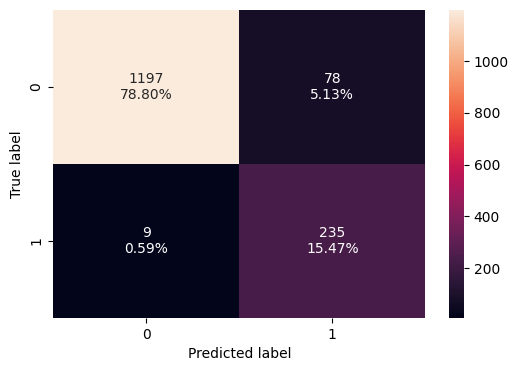

In [135]:
#Create the confusion matrix
confusion_matrix_sklearn(tuned_adbunder, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 78.87%.
* The model has a moderate True Positive (TP) rate predicted at 15.47%.
* The model shows a high overall accuracy of 94.3%, indicating that it performs well on the validation dataset after under sampling.
* The high recall of 96.3% approximately indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 5.7% of the instances wrongly

#### Tuning Gradient Boosting with Oversampled data

In [136]:
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.05, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.7963250637607233:


In [137]:
# Creating new pipeline with best parameters
tuned_gbover = GradientBoostingClassifier(init=DecisionTreeClassifier(random_state=1),learning_rate=0.05,max_features=0.7,n_estimators=100,subsample=0.7)

# Fit the model on training data
tuned_gbover.fit(X_train_over, y_train_over)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_gbover, X_train_over, y_train_over))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_gbover, X_val, y_val))

Train Performance:
   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.928   0.848      0.739 0.790


##### Observation:
* The Gradient Boosting with over sampled data has a recall score of 84.8% performance on the validation data after hyperparameter tuning.

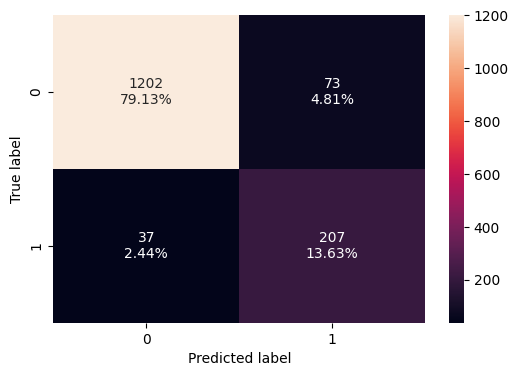

In [138]:
#Create confusion matrix
confusion_matrix_sklearn(tuned_gbover, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 79.13%.
* The model has a low True Positive (TP) rate predicted at 13.63%.
* The model shows a high overall accuracy of 92.8%, indicating that it performs well on the validation dataset after over sampling.
* The high recall of 84.8% approximately indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 7.2% of the instances wrongly.

#### Tuning Adaboost with Oversampled Data

In [139]:
# Check Adaboosting model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8577904011129146:


In [140]:
# Creating new pipeline with best parameters
tuned_adbover = AdaBoostClassifier(n_estimators=100,learning_rate=0.1, base_estimator = DecisionTreeClassifier(max_depth=3, random_state=1))

# Fit the model on training data
tuned_adbover.fit(X_train_over, y_train_over)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_adbover, X_train_over, y_train_over))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_adbover, X_val, y_val))

Train Performance:
   Accuracy  Recall  Precision    F1
0     0.984   0.985      0.983 0.984
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.972   0.930      0.901 0.915


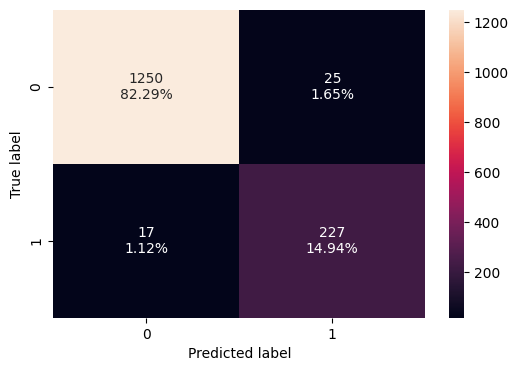

In [141]:
#Creating confusion matrix
confusion_matrix_sklearn(tuned_adbover, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 82.36%.
* The model has a moderate True Positive (TP) rate predicted at 14.94%.
* The model shows a high overall accuracy of 97.3%, indicating that it performs well on the validation dataset after over sampling.
* The high recall of 93.0% indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 2.7% of the instances wrongly.

#### Tuning Adaboost with Original data

In [142]:
# Check Adaboosting model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8577904011129146:


In [143]:
# Creating new pipeline with best parameters
tuned_adb_ori = AdaBoostClassifier(n_estimators=100,learning_rate=0.1, base_estimator = DecisionTreeClassifier(max_depth=3, random_state=1))

# Fit the model on training data
tuned_adb_ori.fit(X_train, y_train)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_adb_ori, X_train, y_train))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_adb_ori, X_val, y_val))

Train Performance:
   Accuracy  Recall  Precision    F1
0     0.983   0.931      0.963 0.946
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.970   0.877      0.934 0.905


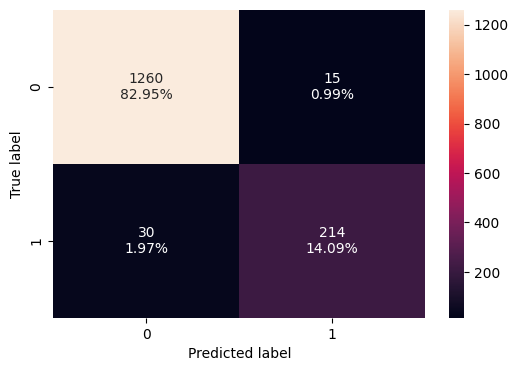

In [144]:
#Create confusion matrix
confusion_matrix_sklearn(tuned_adb_ori, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 82.95%.
* The model has a low True Positive (TP) rate predicted at 14.09%.
* The model shows a high overall accuracy of 97.0%, indicating that it performs well on the validation dataset of the original data.
* The high recall of 87.7% approximately indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 3.0% of the instances wrongly.

#### Tuning Gradientboost with original data

In [145]:
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.05, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.7963250637607233:


In [146]:
# Creating new pipeline with best parameters
tuned_gb_ori = GradientBoostingClassifier(init=DecisionTreeClassifier(random_state=1),learning_rate=0.05,max_features=0.7,n_estimators=100,subsample=0.7)

# Fit the model on training data
tuned_gb_ori.fit(X_train, y_train)

# Make predictions on the train data
#y_train_pred = Model_best.predict(X_train_under)

# Make predictions on the validation data
#y_val_pred = Model_best.predict(X_val)

# Print the performance metrics for train and validation data
print("Train Performance:")
print(model_performance_classification_sklearn(tuned_gb_ori, X_train, y_train))
print("Validation Performance:")
print(model_performance_classification_sklearn(tuned_gb_ori, X_val, y_val))



Train Performance:
   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Validation Performance:
   Accuracy  Recall  Precision    F1
0     0.936   0.807      0.798 0.802


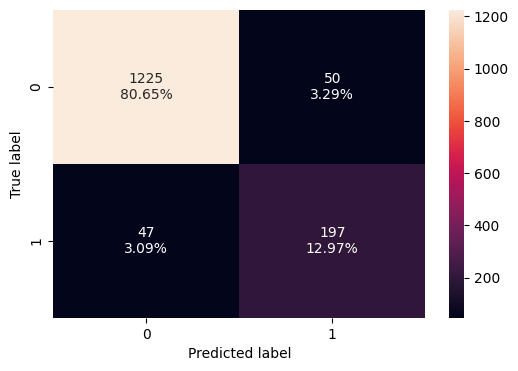

In [147]:
#Create confusion matrix
confusion_matrix_sklearn(tuned_gb_ori, X_val, y_val)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 80.65% (approximately 80.7%).
* The model has a low True Positive (TP) rate predicted at 12.97%.
* The model shows a high overall accuracy of 93.6%, indicating that it performs well on the validation dataset of the original data.
* The high recall of 80.7% approximately indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 6.4% of the instances wrongly.

## Model Comparison and Final Model Selection

Gradient Boosting Tuned Undersampled: 0.704592 (0.073022)
Gradient Boosting Tuned Oversampled: 0.704592 (0.073022)
Gradient Boosting Tuned Original: 0.704592 (0.073022)
Adaboost Tuned Undersampled: 0.782993 (0.051915)
Adaboost Tuned Oversampled: 0.782993 (0.053496)
Adaboost Tuned Original: 0.787075 (0.051969)


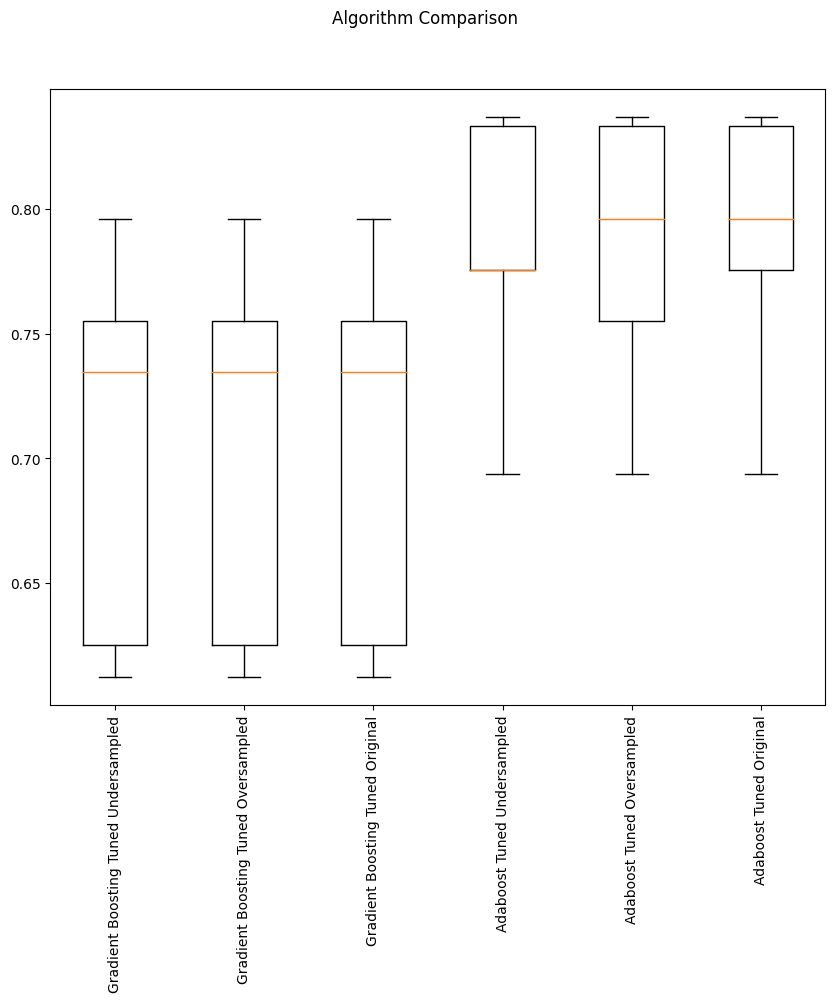

In [148]:
models_comp = []
models_comp.append(("Gradient Boosting Tuned Undersampled", tuned_gbunder))
models_comp.append(("Gradient Boosting Tuned Oversampled", tuned_gbover))
models_comp.append(("Gradient Boosting Tuned Original", tuned_gb_ori))
models_comp.append(("Adaboost Tuned Undersampled", tuned_adbunder))
models_comp.append(("Adaboost Tuned Oversampled", tuned_adbover))
models_comp.append(("Adaboost Tuned Original", tuned_adb_ori))

# Evaluating the performance on the validation dataset
results = []
names = []
scoring = 'recall'
for name, model in models_comp:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_results = cross_val_score(model, X_val, y_val, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Plotting boxplots of the 5-fold cross validation scores
fig = plt.figure(figsize=(10,8))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.xticks(rotation=90)
plt.show()

##### Observation:
* The Adaboost Tuned undersampled model is the best model as it has the highest mean cross validation score of 0.787075.
* The Adaboost Tuned Original and Adaboost Tuned oversampled are the second best models with a mean cross validation score of 0.782993.
* All the Gradient Boosting models have a mean cross validation score of 0.704592.

### Test set final performance

In [149]:
# Assign the tuned_adbunder to the  best_model variable
best_model = tuned_adbunder

# Fit the best model on the entire training data (including validation)
best_model.fit(np.concatenate((X_train, X_val)), np.concatenate((y_train, y_val)))

# Make predictions on the test data
y_test_pred = best_model.predict(X_test)

# Evaluate the performance on the test dataset
print("Test Performance:")
print(model_performance_classification_sklearn(best_model, X_test, y_test))

Test Performance:
   Accuracy  Recall  Precision    F1
0     0.969   0.873      0.930 0.901


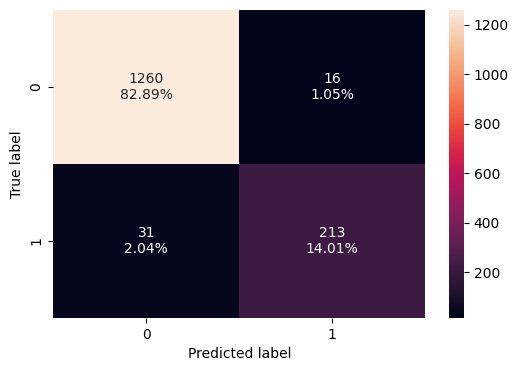

In [150]:
#create confusion matrix
confusion_matrix_sklearn(best_model, X_test, y_test)

##### Observations:
* The model has a high True Negative (TN) rate predicted at 82.89% (approximately 82.9%).
* The model has a low True Positive (TP) rate predicted at 14.01%.
* The model shows a high overall accuracy of 96.9%, indicating that it performs well on the test dataset.
* The high recall of 87.3% indicates that the model is effective at identifying most positive/correct instances.
* The model only predicted 3.1% of the instances wrongly.
* The test model is very good at predicting customer would likely stop using their credit cards.

#### Feature Importance

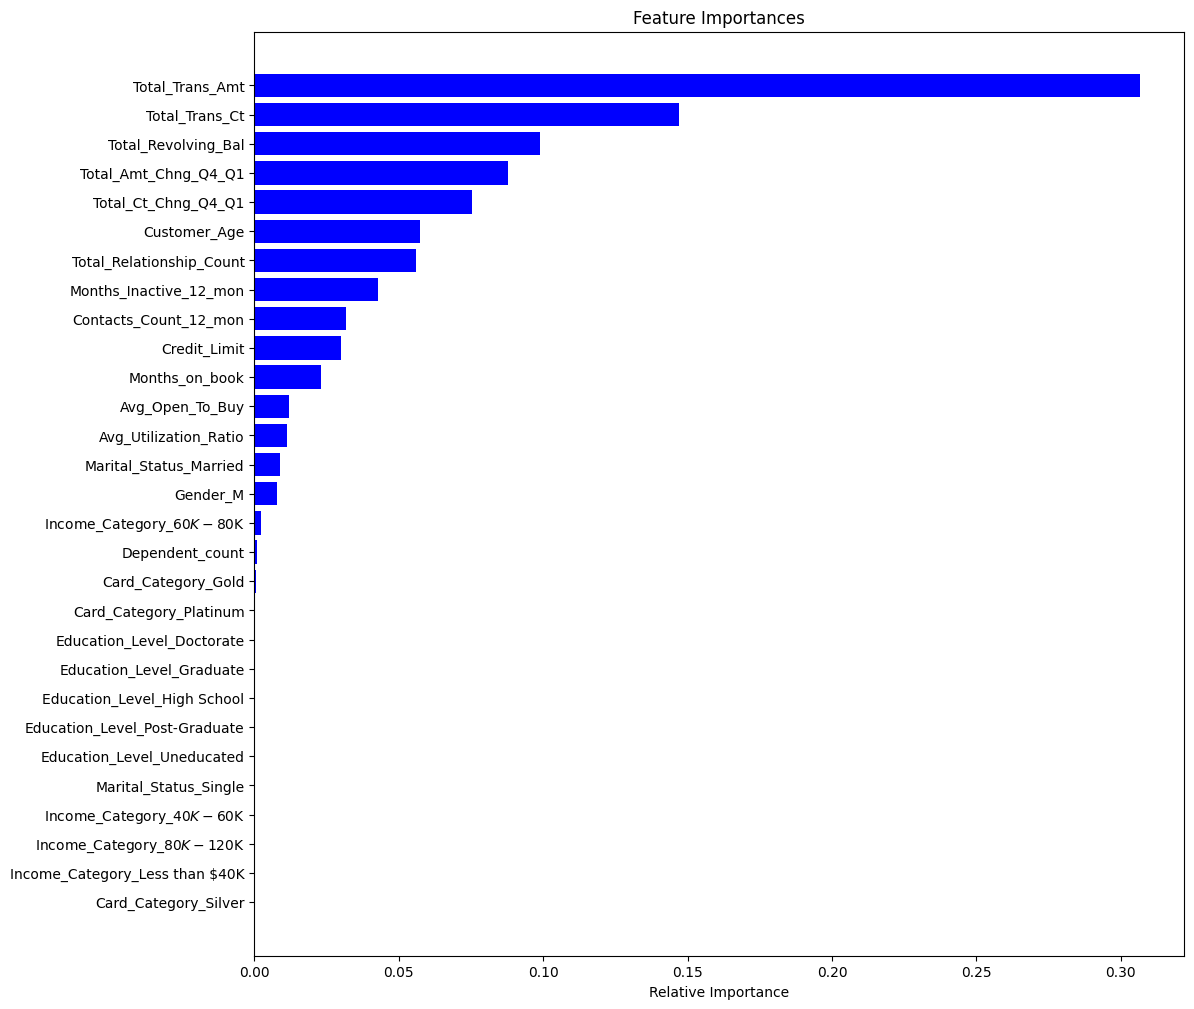

In [151]:
# Feature Importance of the best model
feature_names = X_train.columns #Stores the X_train columns in the features_names variable
importances = best_model.feature_importances_
indices = np.argsort(importances)

# Plot the feature importances
plt.figure(figsize=(12, 12)) # Sets the size of the graph
plt.title("Feature Importances") # Sets the title of the Graph
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show() # Shows the graph

##### Observations:
* The variable with the highest feature importance is Total transaction amount (Total_Trans_Amt) with over 30% relative importance, suggesting that it plays a crucial role in predicting attrition customer.
* The total transaction count (Total_Trans_Ct) is the second most important feature and it suggest that the frequency of transactions is also a strong predictors in the model.
* Total revolving balance (Total_Revolving_Bal) is variable with the third feature importance. It suggest that the amount of revolving balance is a key factor in assessing the financial stability of the customers.
* The variable with the least feature importance is Total transaction amount (Card_Category_Silver).

# Business Insights and Conclusions

 **Business Insights:**

* Based on the EDA, it is recommended that the bank should increase customer engagement by focusing on strategies such as targeted marketing, loyalty programs to increase transaction counts and amount.
* The bank should monitor and support high revolving balance customers by providing financial advice and support to them to help them manage their finances better and reduce attrition.
* The bank should use credit limit and utilization ratio data to identify customers at risk of attrition and tailor intervention accordingly.
* By effectively identifying the attrition flag as the target variable, the model will help the bank to improve customer retention, optimise resource allocation.
* The model's prediction can be used by the bank to organised personalised marketing campaigns, prioritize customer support efforts.



**Conclusions:**

* The Adaboost model tuned with undersampled data achieved the best performance on the
validation set.
* The model will help the bank to improve customer retention, optimise resource allocation as it has a high prediction state for customers who would like stop using their credit cards.

* The model's performance on the test set suggests that it generalizes well to unseen data and can be deployed in a real-world setting.

* Further improvements in the model performance could be achieved by collecting more data, exploring additional features, or experimenting with different algorithms.




In [152]:
!jupyter nbconvert --to html '/content/drive/MyDrive/Advanced_Machine_Learning/AML_Project_LearnerNotebook_FullCode.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Advanced_Machine_Learning/AML_Project_LearnerNotebook_FullCode.ipynb to html
[NbConvertApp] Writing 1613184 bytes to /content/drive/MyDrive/Advanced_Machine_Learning/AML_Project_LearnerNotebook_FullCode.html


***